<a href="https://colab.research.google.com/github/SURYABALA03/23CSE301-ML-24057/blob/main/ML5_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 500

trip_miles = np.round(np.random.uniform(1,20,rows),2)

trip_seconds = np.random.randint(300,3600,rows)

fare = (
    3.5
    + trip_miles*2.8
    + trip_seconds*0.015
    + np.random.normal(0,2,rows)
)

fare = np.round(fare,2)

df = pd.DataFrame({
    "trip_miles":trip_miles,
    "trip_seconds":trip_seconds,
    "fare":fare
})

df.to_csv("taxi_fare_dataset.csv",index=False)

print("Dataset Created Successfully")

df.head()

Dataset Created Successfully


,trip_miles,trip_seconds,fare
0,8.12,2849,67.77
1,19.06,3306,109.06
2,14.91,3516,96.73
3,12.37,1524,60.01
4,3.96,1228,33.85


In [6]:
df = pd.read_csv("taxi_fare_dataset.csv")

df.head()

,trip_miles,trip_seconds,fare
0,8.12,2849,67.77
1,19.06,3306,109.06
2,14.91,3516,96.73
3,12.37,1524,60.01
4,3.96,1228,33.85


In [7]:
df.tail()

,trip_miles,trip_seconds,fare
495,7.71,3504,78.23
496,12.09,3235,83.75
497,2.48,2163,43.07
498,19.51,426,64.65
499,19.74,3477,111.17


In [8]:
print(df.shape)

(500, 3)


In [9]:
df.columns

Index(['trip_miles', 'trip_seconds', 'fare'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_miles    500 non-null    float64
 1   trip_seconds  500 non-null    int64  
 2   fare          500 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [11]:
df.isnull().sum()

,0
trip_miles,0
trip_seconds,0
fare,0


In [12]:
df.describe()

,trip_miles,trip_seconds,fare
count,500.000000,500.000000,500.000000
mean,10.472580,2000.468000,62.919380
std,5.675233,953.653038,21.748248
min,1.100000,303.000000,10.110000
25%,5.587500,1167.000000,46.035000
50%,10.750000,2137.000000,63.425000
75%,15.370000,2818.250000,78.782500
max,19.870000,3587.000000,114.340000


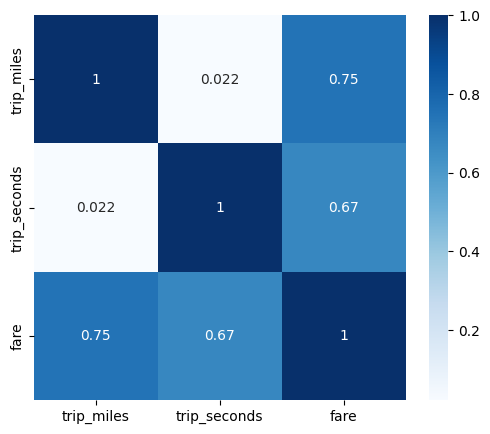

In [13]:
plt.figure(figsize=(6,5))

sns.heatmap(df.corr(),annot=True,cmap="Blues")

plt.show()

In [14]:
X = df[["trip_miles","trip_seconds"]]

y = df["fare"]

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train,y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [19]:
result = pd.DataFrame({
    "Actual Fare":y_test,
    "Predicted Fare":y_pred
})

result.head(10)

,Actual Fare,Predicted Fare
361,72.31,69.271220
73,69.33,67.609025
374,39.63,42.372168
155,71.97,72.766764
104,94.72,91.649893
394,63.89,64.188857
377,31.92,30.734288
124,69.73,70.666164
68,20.67,15.420111
450,67.99,64.584505


In [20]:
mae = mean_absolute_error(y_test,y_pred)

print("Mean Absolute Error =",mae)

Mean Absolute Error = 1.7010971150212528


In [21]:
mse = mean_squared_error(y_test,y_pred)

print("Mean Squared Error =",mse)

Mean Squared Error = 4.770659165650422


In [22]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error =",rmse)

Root Mean Squared Error = 2.1841838671802383


In [23]:
r2 = r2_score(y_test,y_pred)

print("R2 Score =",r2)

R2 Score = 0.9889522877962522


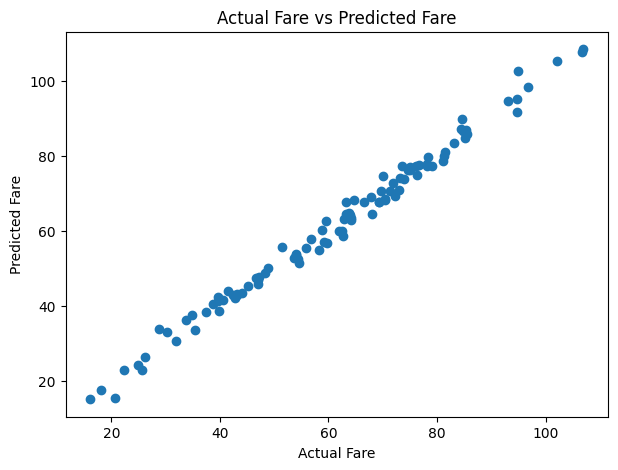

In [24]:
plt.figure(figsize=(7,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Fare")

plt.ylabel("Predicted Fare")

plt.title("Actual Fare vs Predicted Fare")

plt.show()

In [25]:
new_trip = pd.DataFrame({
    "trip_miles":[10],
    "trip_seconds":[1500]
})

prediction = model.predict(new_trip)

print("Predicted Fare = $",round(prediction[0],2))

Predicted Fare = $ 54.11
